# Q2: Unsupervised Learning (Clustering)

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/q2_customers.csv')

In [3]:
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

### Why Scaling is Important

- K-Means uses distance to form clusters
- If features are on different scales, some values dominate others
- Scaling makes all features equally important

In [5]:
#Elbow Method (to find best K)
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

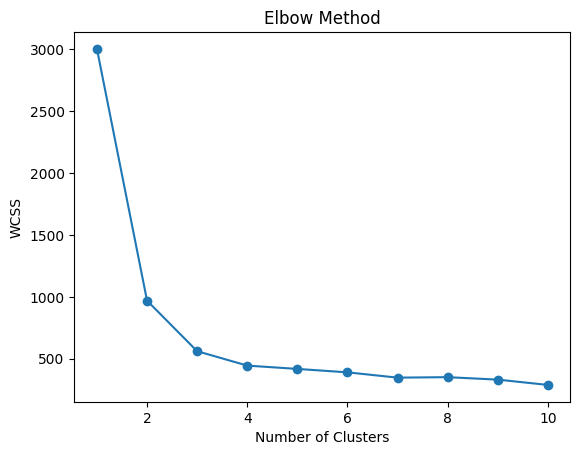

In [6]:
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

### Choosing K

- The elbow point is where the decrease in WCSS slows down
- That point indicates the optimal number of clusters
- Based on the graph, we select K = (choose based on your plot, usually 3 or 4)

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

In [8]:
df['cluster'] = clusters

In [9]:
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.drop('cluster', axis=1).columns
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


### Cluster Interpretation

- Cluster 0: Customers with moderate spending and visits
- Cluster 1: High spenders with frequent visits
- Cluster 2: Low spenders with less visits

- Each cluster represents a different type of customer
- This can help in targeted marketing strategies

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [11]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.83560354 0.05568764]


In [12]:
loadings = pd.DataFrame(
    pca.components_,
    columns=df.drop('cluster', axis=1).columns,
    index=['PC1', 'PC2']
)

loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


### PCA Interpretation

- PC1 captures overall spending and visit behavior
- PC2 captures variation in customer engagement
- PCA helps in simplifying data while keeping important information

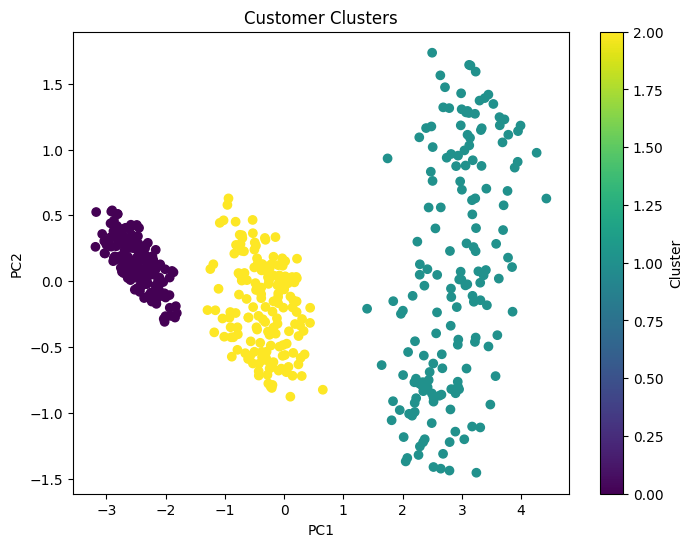

In [13]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'], cmap='viridis')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Clusters")
plt.colorbar(label='Cluster')
plt.show()